In [26]:
!pip install -r dados_finais/requirements.txt

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\kairo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [27]:
# Inicializando o Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col, coalesce, lit, count, avg, round as spark_round, sum as spark_sum
spark = SparkSession.builder.master("local[*]").appName("Tic_Kids_Analise").getOrCreate()

In [28]:
#Criação do dataset unificado tic kids
dataset = spark.read.csv('dados_finais/dados_tic_kids_geral_csv.csv', header=True, inferSchema=True, multiLine=True, escape='"')

#Esse código faz com que caso um dos valores das colunas de USO de Rede Social da linha seja Sim o resultado final vai ser Sim
uso_redes_1 = col(dataset.columns[6])
uso_redes_2 = col(dataset.columns[12])
uso_redes_3 = col(dataset.columns[16])

respostas_nao_contaveis = ["Não sabe", "Não respondeu", "Não se aplica"]

dataset_unificado = dataset.withColumn(
    "uso_rede_social",
    when((uso_redes_1 == "Sim") | (uso_redes_2 == "Sim") | (uso_redes_3 == "Sim"),"Sim")
    .when((uso_redes_1 == "Não") | (uso_redes_2 == "Não") | (uso_redes_3 == "Não"),"Não")
    .otherwise("Não se aplica ou Não sabe/respondeu")
)

#Esse código faz com que caso um dos valores das colunas de FREQUENCIA da linha seja a
#resposta de maior intensidade de uso das redes (Mais de uma vez por dia) o resultado final vai ser a resp de maior intensidade de uso das redes
#Ex: Caso o aluno use o Whatsapp uma vez por dia, mas usa o Tiktok uma vez por semana dá pra se constar que ele usa as Redes Sociais mais de uma vez por dia
freq_redes_1 = col(dataset.columns[7])
freq_redes_2 = col(dataset.columns[13])
freq_redes_3 = col(dataset.columns[17])

dataset_unificado = dataset_unificado.withColumn(
    "freq_rede_social",
    when((freq_redes_1 == "Mais de uma vez por dia") | (freq_redes_2 == "Mais de uma vez por dia") |
         (freq_redes_3 == "Mais de uma vez por dia"),"Mais de uma vez por dia")
    .when((freq_redes_1 == "Pelo menos uma vez por dia") | (freq_redes_2 == "Pelo menos uma vez por dia") |
         (freq_redes_3 == "Pelo menos uma vez por dia"),"Pelo menos uma vez por dia")
    .when((freq_redes_1 == "Pelo menos uma vez por semana") | (freq_redes_2 == "Pelo menos uma vez por semana") |
         (freq_redes_3 == "Pelo menos uma vez por semana"),"Pelo menos uma vez por semana")
    .when((freq_redes_1 == "Pelo menos uma vez por mês") | (freq_redes_2 == "Pelo menos uma vez por mês") |
         (freq_redes_3 == "Pelo menos uma vez por mês"),"Pelo menos uma vez por mês")
    .when((freq_redes_1 == "Menos de uma vez por mês") | (freq_redes_2 == "Menos de uma vez por mês") |
         (freq_redes_3 == "Menos de uma vez por mês"),"Menos de uma vez por mês")
    .otherwise("Não se aplica ou Não sabe/respondeu")
)

#Esse código unifica as duas colunas de Região
regiao_1 = col(dataset.columns[2])
regiao_2 = col(dataset.columns[15])

dataset_unificado = dataset_unificado.withColumn(
    "Região",
    coalesce(regiao_1, regiao_2)
)

serie = col(dataset.columns[0])

dataset_unificado = dataset_unificado.withColumn(
    "Em que ano a criança/adolescente está na escola?",
    when((serie == "1º ano do ensino Fundamental / Pré"),"Pré")
    .when((serie == "2º ano do Ensino Fundamental / 1ª série do Ensino Fundamental"),"1º série do Ensino Fundamental")
    .when((serie == "3º ano do Ensino Fundamental / 2ª série do Ensino Fundamental"),"2º série do Ensino Fundamental")
    .when((serie == "4º ano do Ensino Fundamental / 3ª série do Ensino Fundamental"),"3ª série do Ensino Fundamental")
    .when((serie == "5º ano do Ensino Fundamental / 4ª série do Ensino Fundamental"),"4ª série do Ensino Fundamental")
    .when((serie == "6º ano do Ensino Fundamental / 5ª série do Ensino Fundamental"),"5ª série do Ensino Fundamental")
    .when((serie == "7º ano do Ensino Fundamental / 6ª série do Ensino Fundamental"),"6ª série do Ensino Fundamental")
    .when((serie == "8º ano do Ensino Fundamental / 7ª série do Ensino Fundamental"),"7ª série do Ensino Fundamental")
    .when((serie == "9º ano do Ensino Fundamental / 8ª série do Ensino Fundamental"),"8ª série do Ensino Fundamental")
    .when((serie.isNull()),"Série não especificada")
    .otherwise(col("Em que ano a criança/adolescente está na escola?"))
)

#Esse código unifica as duas colunas de Faixa Etária
etaria_1 = col(dataset.columns[1])
etaria_2 = col(dataset.columns[14])

dataset_unificado = dataset_unificado.withColumn(
    "faixa_etaria",
    coalesce(etaria_1, etaria_2)
)

frequencias = ["Mais de uma vez por dia", "Pelo menos uma vez por dia", "Pelo menos uma vez por semana", "Pelo menos uma vez por mês", "Menos de uma vez por mês", "Não se aplica ou Não sabe/respondeu"]

dataset_tickids_unificado = dataset_unificado.select("Ano","Em que ano a criança/adolescente está na escola?", "uso_rede_social","freq_rede_social", "Região","faixa_etaria")
dataset_tickids_unificado_nordeste = dataset_tickids_unificado.filter((col("Região") == "Nordeste") & (col("uso_rede_social").isin("Sim", "Não") & (col("freq_rede_social").isin(frequencias))))

dataset_tickids_unificado_nordeste.show(50000,truncate=False)

+----+------------------------------------------------+---------------+-----------------------------------+--------+---------------+
|Ano |Em que ano a criança/adolescente está na escola?|uso_rede_social|freq_rede_social                   |Região  |faixa_etaria   |
+----+------------------------------------------------+---------------+-----------------------------------+--------+---------------+
|2017|8ª série do Ensino Fundamental                  |Sim            |Mais de uma vez por dia            |Nordeste|De 13 a 14 anos|
|2017|1º ano do Ensino Médio                          |Sim            |Mais de uma vez por dia            |Nordeste|De 13 a 14 anos|
|2017|3º ano do Ensino Médio                          |Sim            |Mais de uma vez por dia            |Nordeste|De 15 a 17 anos|
|2017|6ª série do Ensino Fundamental                  |Sim            |Pelo menos uma vez por semana      |Nordeste|De 11 a 12 anos|
|2017|1º ano do Ensino Médio                          |Sim           

In [29]:
#Criação do dataset unificado inep

dataset_inep = spark.read.csv('dados_finais/dados_inep_geral_csv.csv', header=True, inferSchema=True, multiLine=True, escape='"')

#Enquadra os estados na sua regiao especifica
regiao = col(dataset_inep.columns[1])
norte = ["Acre", "Amapá", "Amazonas", "Pará", "Rondônia", "Roraima", "Tocantins"]
nordeste = ["Alagoas", "Bahia", "Ceará", "Maranhão", "Paraíba", "Pernambuco", "Piauí", "Rio Grande do Norte", "Sergipe"]
centro_oeste = ["Distrito Federal", "Goiás", "Mato Grosso", "Mato Grosso do Sul"]
sudeste = ["Espírito Santo", "Minas Gerais", "Rio de Janeiro", "São Paulo"]
sul = ["Paraná", "Santa Catarina", "Rio Grande do Sul"]
dataset_inep_novo = dataset_inep.withColumn(
    "Região",
    when(regiao.isin(norte), "Norte")
    .when(regiao.isin(nordeste), "Nordeste")
    .when(regiao.isin(centro_oeste), "Centro_Oeste")
    .when(regiao.isin(sudeste), "Sudeste")
    .when(regiao.isin(sul), "Sul")
    .otherwise(col("Unidade_Geografica"))
)

#Transforma tudo q é nulo em não se sabe
dataset_inep_novo = dataset_inep_novo.withColumn(
    "Aprovação Ensino Fundamental",
    when((col("Aprovacao_Ensino_Fundamental").isNull()), "Não se sabe")
    .otherwise((col("Aprovacao_Ensino_Fundamental")))
)
dataset_inep_novo = dataset_inep_novo.withColumn(
    "Aprovação Ensino Médio",
    when((col("Aprovacao_Ensino_Medio").isNull()), "Não se sabe")
    .otherwise((col("Aprovacao_Ensino_Medio")))
)
dataset_inep_novo = dataset_inep_novo.withColumn(
    "Reprovação Ensino Fundamental",
    when((col("Reprovacao_Ensino_Fundamental").isNull()), "Não se sabe")
    .otherwise((col("Reprovacao_Ensino_Fundamental")))
)
dataset_inep_novo = dataset_inep_novo.withColumn(
    "Reprovação Ensino Médio",
    when((col("Reprovacao_Ensino_Medio").isNull()), "Não se sabe")
    .otherwise((col("Reprovacao_Ensino_Medio")))
)

#Exclui as linhas que dizem a Fonte do INEP
anos = [2017,2018,2019,2021,2022,2023,2024]
dataset_inep_final = dataset_inep_novo.filter(
    col("Ano").isin(anos) & (col("Região") == "Nordeste") &
    (col("Aprovação Ensino Fundamental") != "Não se sabe") &
    (col("Aprovação Ensino Médio") != "Não se sabe") &
    (col("Reprovação Ensino Fundamental") != "Não se sabe") &
    (col("Reprovação Ensino Médio") != "Não se sabe")
    )


#Dataset unificado final
dataset_inep_unificado = dataset_inep_final.select("Ano","Região","Aprovação Ensino Fundamental","Reprovação Ensino Fundamental","Aprovação Ensino Médio","Reprovação Ensino Médio")

#Linha feita apenas pra vizualizar o dataset
dataset_inep_unificado_nordeste = dataset_inep_unificado.orderBy("Região")
dataset_inep_unificado_nordeste.show(5000,truncate=False)

+----+--------+----------------------------+-----------------------------+----------------------+-----------------------+
|Ano |Região  |Aprovação Ensino Fundamental|Reprovação Ensino Fundamental|Aprovação Ensino Médio|Reprovação Ensino Médio|
+----+--------+----------------------------+-----------------------------+----------------------+-----------------------+
|2017|Nordeste|88.0                        |9.3                          |83.0                  |10.0                   |
|2017|Nordeste|88.3                        |9.1                          |82.9                  |10.2                   |
|2017|Nordeste|87.1                        |9.9                          |83.3                  |8.5                    |
|2017|Nordeste|96.4                        |3.6                          |82.3                  |14.0                   |
|2017|Nordeste|96.3                        |3.7                          |82.0                  |14.3                   |
|2017|Nordeste|97.3     

In [30]:
#Transformando os dados do Tic Kids em porcentagem para poder dar join com o Inep, cada linha será um ano com todas as porcentagens de uso e frequencia de rede social

#Contando a quantidade das respostas de cada tipo por ano
dataset_tickids_porcentagem = dataset_tickids_unificado_nordeste.groupBy("Ano").agg(
    count(lit(1)).alias("total_alunos"),
    
    spark_sum(when(col("uso_rede_social") == "Sim", 1).otherwise(0)).alias("qtd_uso_sim"),
    spark_sum(when(col("uso_rede_social") == "Não", 1).otherwise(0)).alias("qtd_uso_nao"),
    
    spark_sum(when(col("freq_rede_social") == "Mais de uma vez por dia", 1).otherwise(0)).alias("qtd_freq_altissima"),
    spark_sum(when(col("freq_rede_social") == "Pelo menos uma vez por dia", 1).otherwise(0)).alias("qtd_freq_alta"),
    spark_sum(when(col("freq_rede_social") == "Pelo menos uma vez por semana", 1).otherwise(0)).alias("qtd_freq_media"),
    spark_sum(when(col("freq_rede_social") == "Pelo menos uma vez por mês", 1).otherwise(0)).alias("qtd_freq_baixa"),
    spark_sum(when(col("freq_rede_social") == "Menos de uma vez por mês", 1).otherwise(0)).alias("qtd_freq_baixissima"),
)

#Calculando a porcentagem de cada resposta
dataset_tickids_porcentagem = dataset_tickids_porcentagem.withColumn(
    "%_uso_sim",
    spark_round((col("qtd_uso_sim") / col("total_alunos")) * 100, 2)
).withColumn(
    "%_uso_nao",
    spark_round((col("qtd_uso_nao") / col("total_alunos")) * 100, 2)
).withColumn(
    "%_freq_altissima",
    spark_round((col("qtd_freq_altissima") / col("total_alunos")) * 100, 2)
).withColumn(
    "%_freq_alta",
    spark_round((col("qtd_freq_alta") / col("total_alunos")) * 100, 2)
).withColumn(
    "%_freq_media",
    spark_round((col("qtd_freq_media") / col("total_alunos")) * 100, 2)
).withColumn(
    "%_freq_baixa",
    spark_round((col("qtd_freq_baixa") / col("total_alunos")) * 100, 2)
).withColumn(
    "%_freq_baixissima",
    spark_round((col("qtd_freq_baixissima") / col("total_alunos")) * 100, 2)
)

print("As duas são a mesma tabela")
print("Porcentagens do uso e frequencia de rede por ano:")
dataset_tickids_porcentagem.orderBy("Ano").select("Ano", "%_uso_sim", "%_uso_nao", "%_freq_altissima", "%_freq_alta", "%_freq_media", "%_freq_baixa", "%_freq_baixissima").show(truncate=False)
print("Quantidades do uso e frequencia de rede por ano:")
dataset_tickids_porcentagem.orderBy("Ano").select("Ano","qtd_uso_sim","qtd_uso_nao","qtd_freq_altissima","qtd_freq_alta","qtd_freq_media","qtd_freq_baixa","qtd_freq_baixissima").show(truncate=False)

As duas são a mesma tabela
Porcentagens do uso e frequencia de rede por ano:
+----+---------+---------+----------------+-----------+------------+------------+-----------------+
|Ano |%_uso_sim|%_uso_nao|%_freq_altissima|%_freq_alta|%_freq_media|%_freq_baixa|%_freq_baixissima|
+----+---------+---------+----------------+-----------+------------+------------+-----------------+
|2017|77.1     |22.9     |55.3            |15.35      |4.14        |1.22        |0.85             |
|2018|72.5     |27.5     |50.07           |14.82      |4.81        |1.34        |1.34             |
|2019|74.8     |25.2     |54.39           |13.91      |3.65        |1.71        |1.14             |
|2021|88.65    |11.35    |66.97           |16.67      |2.71        |1.31        |0.9              |
|2022|87.36    |12.64    |65.38           |16.7       |3.3         |0.66        |0.99             |
|2023|88.36    |11.64    |67.78           |14.01      |3.99        |1.08        |1.4              |
|2024|86.33    |13.67  

In [31]:
#Agregando os dados do INEP para o join

#Transformando as taxas para números que possam ser agregados em média
dataset_inep_preparado = dataset_inep_unificado_nordeste.filter(
    (col("Aprovação Ensino Fundamental") != "Não se sabe") &
    (col("Reprovação Ensino Fundamental") != "Não se sabe")
).withColumn(
    "taxa_aprovacao_fundamental",
    col("Aprovação Ensino Fundamental").cast("double")
).withColumn(
    "taxa_reprovacao_fundamental",
    col("Reprovação Ensino Fundamental").cast("double")
).withColumn(
    "taxa_aprovacao_medio",
    col("Aprovação Ensino Médio").cast("double")
).withColumn(
    "taxa_reprovacao_medio",
    col("Reprovação Ensino Médio").cast("double")
)

#Fazendo a média das taxas para cada ano no Nordeste
dataset_inep_agregado = dataset_inep_preparado.groupBy("Ano").agg(
    avg("taxa_aprovacao_fundamental").alias("Média Aprovação Fundamental"),
    avg("taxa_reprovacao_fundamental").alias("Média Reprovação Fundamental"),
    avg("taxa_aprovacao_medio").alias("Média Aprovação Médio"),
    avg("taxa_reprovacao_medio").alias("Média Reprovação Médio")
)

print("\nINEP AGREGADO - Média de todos os estados do Nordeste por ano:")
dataset_inep_agregado.orderBy("Ano").show(truncate=False)


INEP AGREGADO - Média de todos os estados do Nordeste por ano:
+----+---------------------------+----------------------------+---------------------+----------------------+
|Ano |Média Aprovação Fundamental|Média Reprovação Fundamental|Média Aprovação Médio|Média Reprovação Médio|
+----+---------------------------+----------------------------+---------------------+----------------------+
|2017|88.60066225165559          |8.865562913907285           |83.68476821192048    |9.213907284768212     |
|2018|89.37302631578942          |8.536842105263162           |84.1361842105263     |8.72565789473684      |
|2019|91.04966887417218          |7.329801324503308           |86.81655629139075    |7.77218543046358      |
|2021|96.10522875816996          |2.247712418300652           |89.80392156862744    |4.194771241830065     |
|2022|92.70066666666666          |5.653333333333333           |87.23666666666665    |6.36                  |
|2023|94.97905405405409          |4.058108108108106           |9

In [32]:
# Criando a coluna de Média Geral de Reprovação, que será Média entre Fundamental e Médio

dataset_inep_MEDIAS = dataset_inep_agregado.withColumn(
    "Média Reprovação Geral",
    (col("Média Reprovação Fundamental") + col("Média Reprovação Médio")) / 2
)

print("Tabela INEP com a Média entre o Ensino Fundamental e Médio:")
dataset_inep_MEDIAS.orderBy("Ano").select(
    "Ano",
    "Média Reprovação Fundamental",
    "Média Reprovação Médio",
    "Média Reprovação Geral"
).show(truncate=False)

Tabela INEP com a Média entre o Ensino Fundamental e Médio:
+----+----------------------------+----------------------+----------------------+
|Ano |Média Reprovação Fundamental|Média Reprovação Médio|Média Reprovação Geral|
+----+----------------------------+----------------------+----------------------+
|2017|8.865562913907285           |9.213907284768212     |9.039735099337747     |
|2018|8.536842105263162           |8.72565789473684      |8.631250000000001     |
|2019|7.329801324503308           |7.77218543046358      |7.550993377483444     |
|2021|2.247712418300652           |4.194771241830065     |3.2212418300653582    |
|2022|5.653333333333333           |6.36                  |6.006666666666667     |
|2023|4.058108108108106           |5.019594594594596     |4.538851351351351     |
|2024|4.037162162162158           |4.638513513513513     |4.337837837837835     |
+----+----------------------------+----------------------+----------------------+



In [33]:
#Juntando as duas tabelas (usando a tabela INEP das Médias)
dataset_inep_tickids_MEDIAS = dataset_tickids_porcentagem.join(
    dataset_inep_MEDIAS,
    on="Ano",
    how="inner"
).orderBy("Ano")

print("Dataset unifcado com: Quantidade e Porcentagem dos valores do TicKids, e Médias do INEP")
dataset_inep_tickids_MEDIAS.orderBy("Ano").show(truncate=False)
print("Dataset Com as Porcentagens do TicKids:")
dataset_inep_tickids_MEDIAS.select("Ano","%_uso_sim","%_uso_nao","%_freq_altissima","%_freq_alta", "%_freq_media", "%_freq_baixa", "%_freq_baixissima").orderBy("Ano").show(truncate=False)
print("Dataset Com as Médias do INEP:")
dataset_inep_tickids_MEDIAS.select("Ano","Média Reprovação Fundamental","Média Reprovação Médio","Média Reprovação Geral").orderBy("Ano").show(truncate=False) 

Dataset unifcado com: Quantidade e Porcentagem dos valores do TicKids, e Médias do INEP
+----+------------+-----------+-----------+------------------+-------------+--------------+--------------+-------------------+---------+---------+----------------+-----------+------------+------------+-----------------+---------------------------+----------------------------+---------------------+----------------------+----------------------+
|Ano |total_alunos|qtd_uso_sim|qtd_uso_nao|qtd_freq_altissima|qtd_freq_alta|qtd_freq_media|qtd_freq_baixa|qtd_freq_baixissima|%_uso_sim|%_uso_nao|%_freq_altissima|%_freq_alta|%_freq_media|%_freq_baixa|%_freq_baixissima|Média Aprovação Fundamental|Média Reprovação Fundamental|Média Aprovação Médio|Média Reprovação Médio|Média Reprovação Geral|
+----+------------+-----------+-----------+------------------+-------------+--------------+--------------+-------------------+---------+---------+----------------+-----------+------------+------------+-----------------+---

In [34]:
#Fazendo a predição da coluna Média Reprovação Geral baseada na coluna %_uso_sim, %_freq_altissima
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

#Transformando o dataset Spark em Pandas para usar o sklearn
df_pandas = dataset_inep_tickids_MEDIAS.toPandas() 

#Escolhendo as variaveis independentes(features), são as variaveis que quero me basear para prever a coluna alvo
X_all = df_pandas[['%_uso_sim', '%_freq_altissima']].values 
#Escolhendo a variavel dependente(target), que é a coluna que quero prever
y_all = df_pandas['Média Reprovação Geral'].values 

#Utilizando o modelo de Regressão Linear para realizar a predição
model = LinearRegression()
model.fit(X_all, y_all) 

y_fit = model.predict(X_all)

#Métricas de Acurácia R² e RMSE

#R² valor entre 0 e 1, quanto mais próximo de 1 melhor o modelo explica a variação dos dados em relação as features
r2 = r2_score(y_all, y_fit)

#RMSE quanto menor melhor, representa a margem de erro das predições da coluna alvo
mse = mean_squared_error(y_all, y_fit)
rmse = np.sqrt(mse)

print("RESULTADOS DA REGRESSÃO LINEAR PREDIZENDO A MÉDIA REPROVAÇÃO ENSINO GERAL")

print("\nValores Reais e Predições de Ajuste (Todo o Dataset):")
df_pred = pd.DataFrame({
    'Ano': df_pandas['Ano'].values,
    '%_uso_sim': df_pandas['%_uso_sim'].values,
    '%_freq_altissima': df_pandas['%_freq_altissima'].values,
    'Valores Reais de Reprovação': y_all.round(2), 
    'Predição': y_fit.round(2), 
    'Erro (Resíduo)': (y_all - y_fit).round(2)
})
print(df_pred.to_string(index=False))

print("-"*70)
print("MÉTRICAS DE ACURÁCIA (AJUSTE HISTÓRICO):")
print(f"R-quadrado (R²): {r2:.4f} (Acurácia: Proporção da variação explicada. Máx: 1.0)")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f} (Erro médio do modelo na unidade do alvo.)")
print("-" * 70)
#Coeficientes Angulares são os pesos atribuidos a cada feature
print(f"Coeficiente Angular USO: {model.coef_[0]:.4f} (Mudança na Reprovação por cada 1% de uso)")
print(f"Coeficiente Angular FREQ: {model.coef_[1]:.4f} (Mudança na Reprovação por cada 1% de freq_altissima)")


RESULTADOS DA REGRESSÃO LINEAR PREDIZENDO A MÉDIA REPROVAÇÃO ENSINO GERAL

Valores Reais e Predições de Ajuste (Todo o Dataset):
 Ano  %_uso_sim  %_freq_altissima  Valores Reais de Reprovação  Predição  Erro (Resíduo)
2017      77.10             55.30                         9.04      7.81            1.23
2018      72.50             50.07                         8.63      9.33           -0.70
2019      74.80             54.39                         7.55      7.85           -0.29
2021      88.65             66.97                         3.22      4.63           -1.41
2022      87.36             65.38                         6.01      5.11            0.90
2023      88.36             67.78                         4.54      4.24            0.30
2024      86.33             66.74                         4.34      4.37           -0.03
----------------------------------------------------------------------
MÉTRICAS DE ACURÁCIA (AJUSTE HISTÓRICO):
R-quadrado (R²): 0.8397 (Acurácia: Proporção da

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


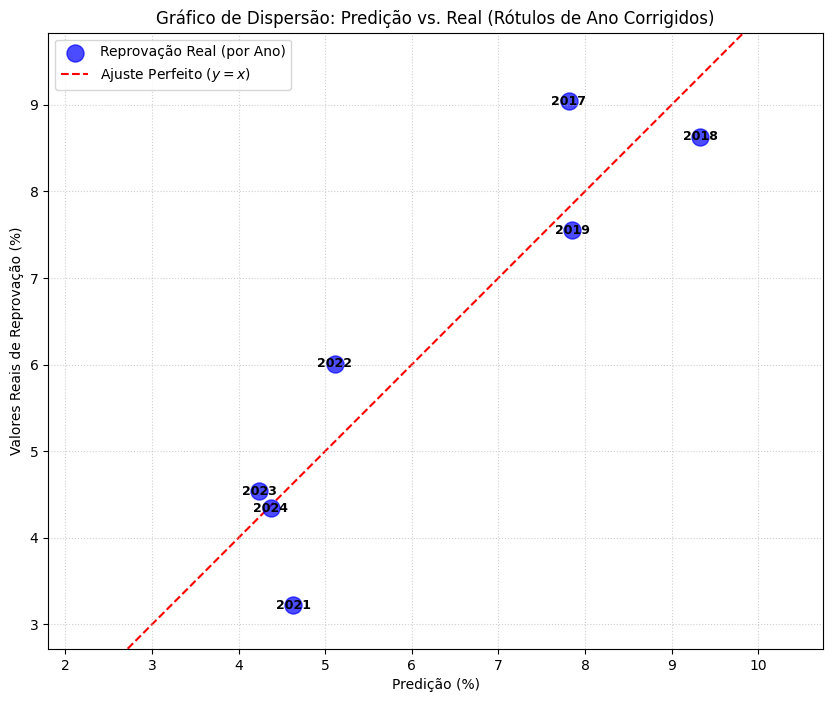

In [35]:
#Fazendo o gráfico de dispersão com os valores reais e preditos
import matplotlib.pyplot as plt

# Preparar os dados para o gráfico de dispersão
dados = {
    'Valores Reais de Reprovação': df_pred['Valores Reais de Reprovação'].tolist(),
    'Predição': df_pred['Predição'].tolist()
}

#Criando o dataframe com os dados para o gráfico e adicionando a coluna Amostra com Indices
df_grafico = pd.DataFrame(dados)
df_grafico['Amostra'] = df_grafico.index + 1

#Mapeando os anos para os indices de Amostra
anos = [2017, 2018, 2019, 2021, 2022, 2023, 2024]
ano_map = {i: anos[i-1] for i in range(1, 8)}
df_grafico['Ano'] = df_grafico['Amostra'].map(ano_map)

#Definindo as colunas para o gráfico e o seu tamanho
X_col = 'Predição'
Y_col = 'Valores Reais de Reprovação'
Label_col = 'Ano'
plt.figure(figsize=(10, 8))

#Criando o grafico de dispersão, onde o eixo X são os valores predizidos e o eixo Y são os valores reais (Média Reprovação)
#São colocados os pontos azuis onde cada ponto representa um Ano e estão localizados nos pares ordenados (Predição, Real)
plt.scatter(
    df_grafico[X_col],
    df_grafico[Y_col],
    color='blue',
    label='Reprovação Real (por Ano)',
    s=150,
    alpha=0.7
)

#Cria a Linha de Ajuste Perfeito onde nela os valores preditos são iguais aos valores reais
#Usada para visualizar o quão perto os pontos estão do ajuste perfeito

#Descobre o menor e maior valor entre os eixos X e Y para definir o intervalo da linha
min_val = df_grafico[[X_col, Y_col]].min().min() - 0.5
max_val = df_grafico[[X_col, Y_col]].max().max() + 0.5

#Cria uma linha de pontos entre o menor e maior valor, entre esses pontos estão 100 valores igualmente espaçados
line_range = np.linspace(min_val, max_val, 100)

plt.plot(
    line_range,
    line_range,
    color='red',
    linestyle='--',
    label='Ajuste Perfeito ($y=x$)',
    zorder=0
)

#Adiciona os Anos como rótulos nos pontos azuis do gráfico
for i in range(len(df_grafico)):
    #Determina o valor previsto, o valor real e o rótulo (Ano) para cada indice
    x = df_grafico.loc[i, X_col]
    y = df_grafico.loc[i, Y_col]
    label = str(df_grafico.loc[i, Label_col])
    
    #Adiciona o rotulo no par ordenado (x,y) 
    plt.text(x, y, label, 
             color='black',
             fontsize=9, 
             ha='center', 
             va='center', 
             fontweight='bold')

#Finalizando a estética do gráfico
plt.title('Gráfico de Dispersão: Predição vs. Real (Rótulos de Ano Corrigidos)')
plt.xlabel(f'{X_col} (%)')
plt.ylabel(f'{Y_col} (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal')
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Exibir o gráfico
plt.show()